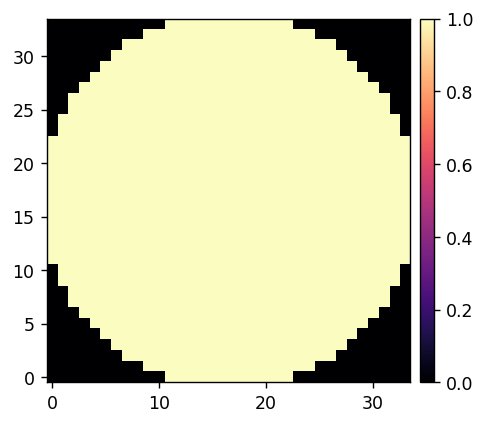

In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoobscc


from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils, telem, dm
from scoobscc import scc
import scoobscc.scoob_interface as scoobi

import scoobpy

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307 / 2 # divide by 2 for bin 1 

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

In [5]:
data_path = str(scoobscc.path)[:-9] + '/data_exp'
exp_path = data_path + '/20250618_iscc_dig_mono'

data = utils.load_pickle(exp_path + '/dig02.pkl')

Text(0, 0.5, 'Mean Contrast')

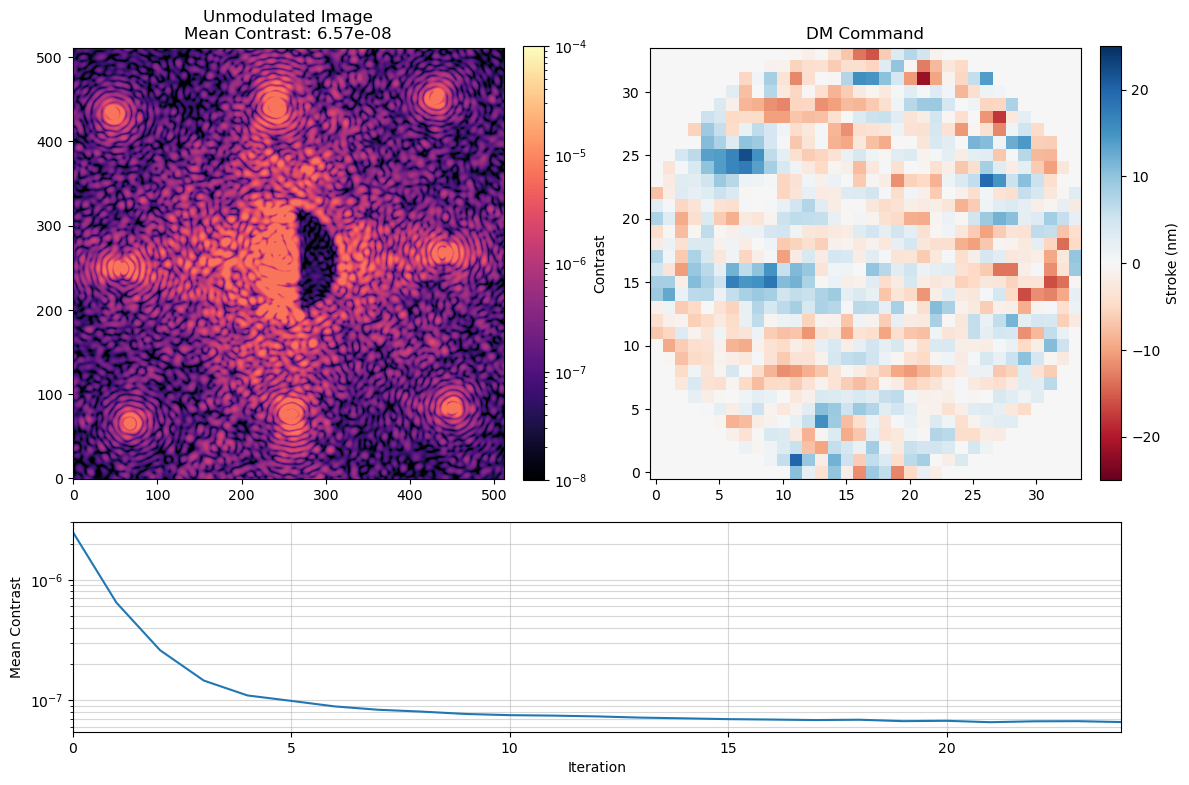

In [6]:
image = data['images_unmod'][-1]
command = data['commands'][-1]
mask = data['control_mask']
contrasts = [np.mean(im[mask]) for im in data['images_unmod']]

fig = plt.figure(figsize=(12, 8), layout='tight')
gs = plt.GridSpec(nrows=3, ncols=4)

ax1 = fig.add_subplot(gs[0:2, 0:2])
m = ax1.imshow(image, norm='log', cmap='magma', vmin=1e-8, vmax=1e-4)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Contrast')
ax1.set_title(f'Unmodulated Image\nMean Contrast: {np.mean(image[mask]):.2e}')

ax2 = fig.add_subplot(gs[0:2, 2:])
m = ax2.imshow(command * 1e9, cmap='RdBu', vmin=-25, vmax=25)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Stroke (nm)')
ax2.set_title('DM Command')

ax3 = fig.add_subplot(gs[2, :])
ax3.semilogy(contrasts)
ax3.grid(which='both', axis='both', alpha=0.5)
ax3.set_xlim([0, len(contrasts) - 1])
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Mean Contrast')

Text(0, 0.5, 'Median Contrast')

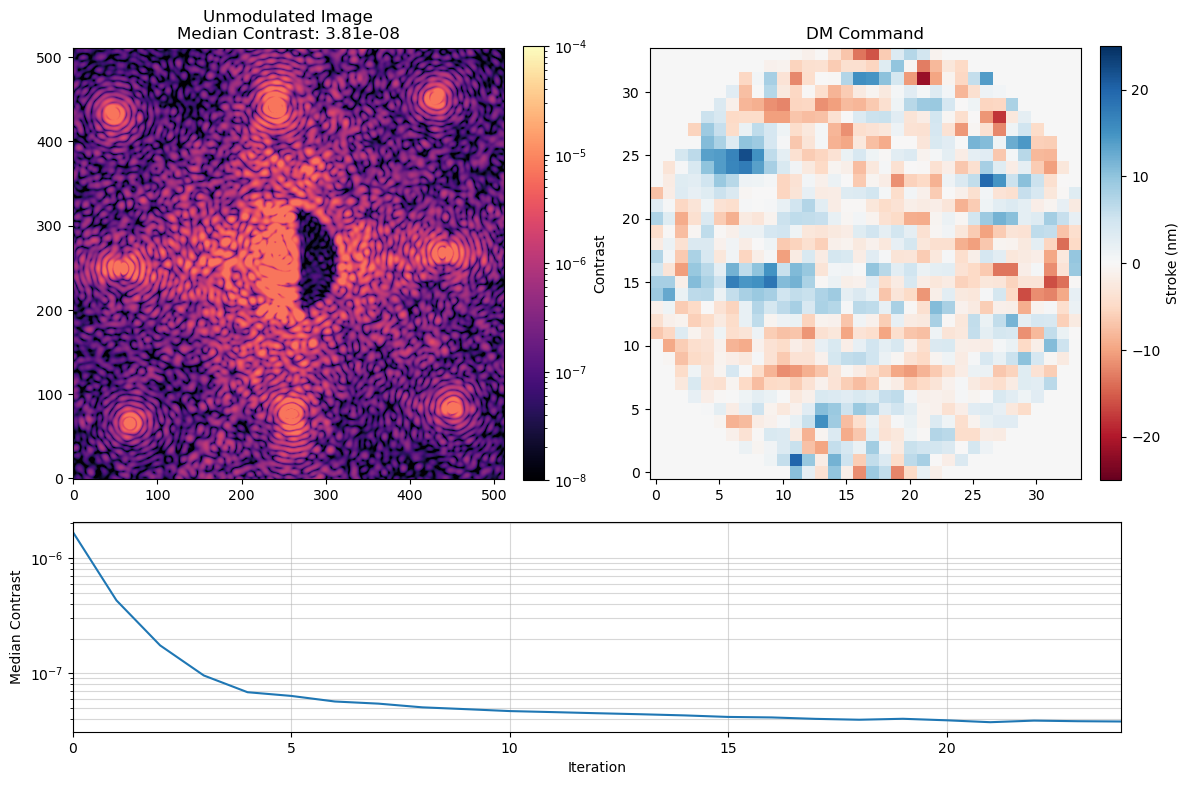

In [4]:
image = data['images_unmod'][-1]
command = data['commands'][-1]
mask = data['control_mask']
contrasts = [np.median(im[mask]) for im in data['images_unmod']]

fig = plt.figure(figsize=(12, 8), layout='tight')
gs = plt.GridSpec(nrows=3, ncols=4)

ax1 = fig.add_subplot(gs[0:2, 0:2])
m = ax1.imshow(image, norm='log', cmap='magma', vmin=1e-8, vmax=1e-4)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Contrast')
ax1.set_title(f'Unmodulated Image\nMedian Contrast: {np.median(image[mask]):.2e}')

ax2 = fig.add_subplot(gs[0:2, 2:])
m = ax2.imshow(command * 1e9, cmap='RdBu', vmin=-25, vmax=25)
plt.colorbar(m, fraction=0.046, pad=0.04, label='Stroke (nm)')
ax2.set_title('DM Command')

ax3 = fig.add_subplot(gs[2, :])
ax3.semilogy(contrasts)
ax3.grid(which='both', axis='both', alpha=0.5)
ax3.set_xlim([0, len(contrasts) - 1])
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Median Contrast')